In [1]:
import os

print(os.listdir("/kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO"))

['labels', 'convert_ssdd.py', 'data.yaml', 'images']


In [2]:
yaml_text = """path: /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO

train: images/train
val: images/val
test: images/test

names:
  0: ship
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_text)

In [3]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [4]:
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/ship_detection",
    name="yolo11n_ssdd_baseline",
    patience=10,
    plots=True
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_ssdd_baseline-2, nbs=64, nm

In [5]:
model = YOLO("/kaggle/working/ship_detection/yolo11n_ssdd_baseline-2/weights/best.pt")

# Validation
test_results = model.val(
    data="/kaggle/working/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/kaggle/working/ship_detection",
    name="test_evaluation"
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.7 ms, read: 11.5±3.1 MB/s, size: 34.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/labels/test... 232 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 410.7it/s 0.6s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.5it/s 2.7s0.1s
                   all        232        546      0.968      0.933      0.985      0.731
Speed: 1.5ms preprocess, 5.6ms inferen

In [6]:
# Prediction

predictions = model.predict(
    source="/kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/kaggle/working/ship_detection",
    name="test_predictions"
)


image 1/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000001.jpg: 512x640 1 ship, 8.1ms
image 2/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000009.jpg: 512x640 1 ship, 9.3ms
image 3/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000011.jpg: 544x640 1 ship, 59.1ms
image 4/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000019.jpg: 544x640 1 ship, 8.4ms
image 5/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000021.jpg: 544x640 2 ships, 8.5ms
image 6/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000029.jpg: 512x640 1 ship, 9.6ms
image 7/232 /kaggle/input/datasets/jagumanish/ssdd-yolo-ship-detection-dataset/SSDD_YOLO/images/test/000031.jpg: 448x640 2 ships, 54.2ms
image 8/232 /kaggle/input/datasets/jagumanish/ssdd

Prediction images: 232
000791.jpg


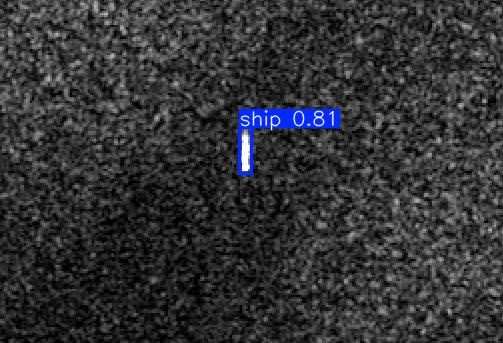

000179.jpg


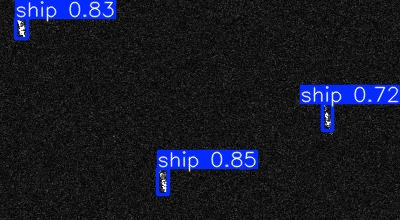

000431.jpg


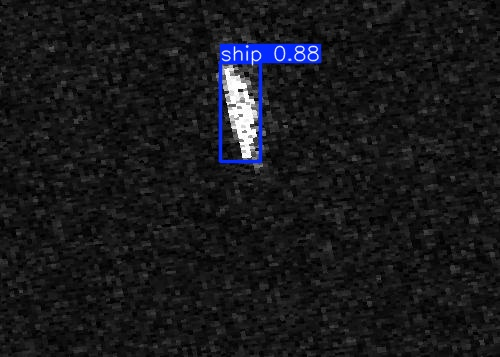

000131.jpg


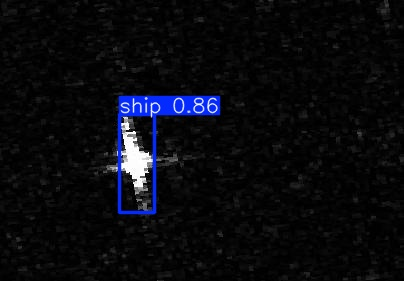

000269.jpg


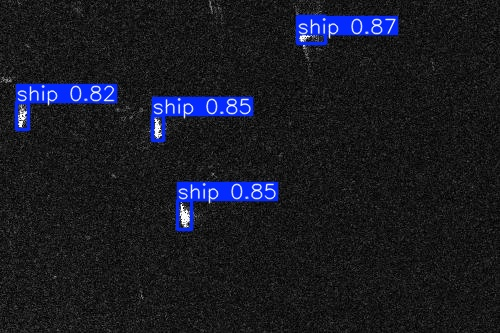

000109.jpg


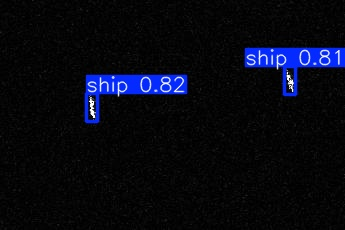

In [7]:
from pathlib import Path
from IPython.display import display, Image
import random

pred_dir = Path("/kaggle/working/ship_detection/test_predictions")
pred_images = list(pred_dir.glob("*.jpg"))
print("Prediction images:", len(pred_images))

for img in random.sample(pred_images, 6):
    print(img.name)
    display(Image(filename=str(img), width=700))

In [8]:
# Confusion Matrix

import os
print(os.listdir("/kaggle/working/ship_detection/test_evaluation"))

['val_batch2_pred.jpg', 'BoxF1_curve.png', 'val_batch2_labels.jpg', 'BoxP_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'BoxR_curve.png', 'val_batch0_pred.jpg', 'val_batch0_labels.jpg', 'BoxPR_curve.png', 'val_batch1_pred.jpg', 'val_batch1_labels.jpg']


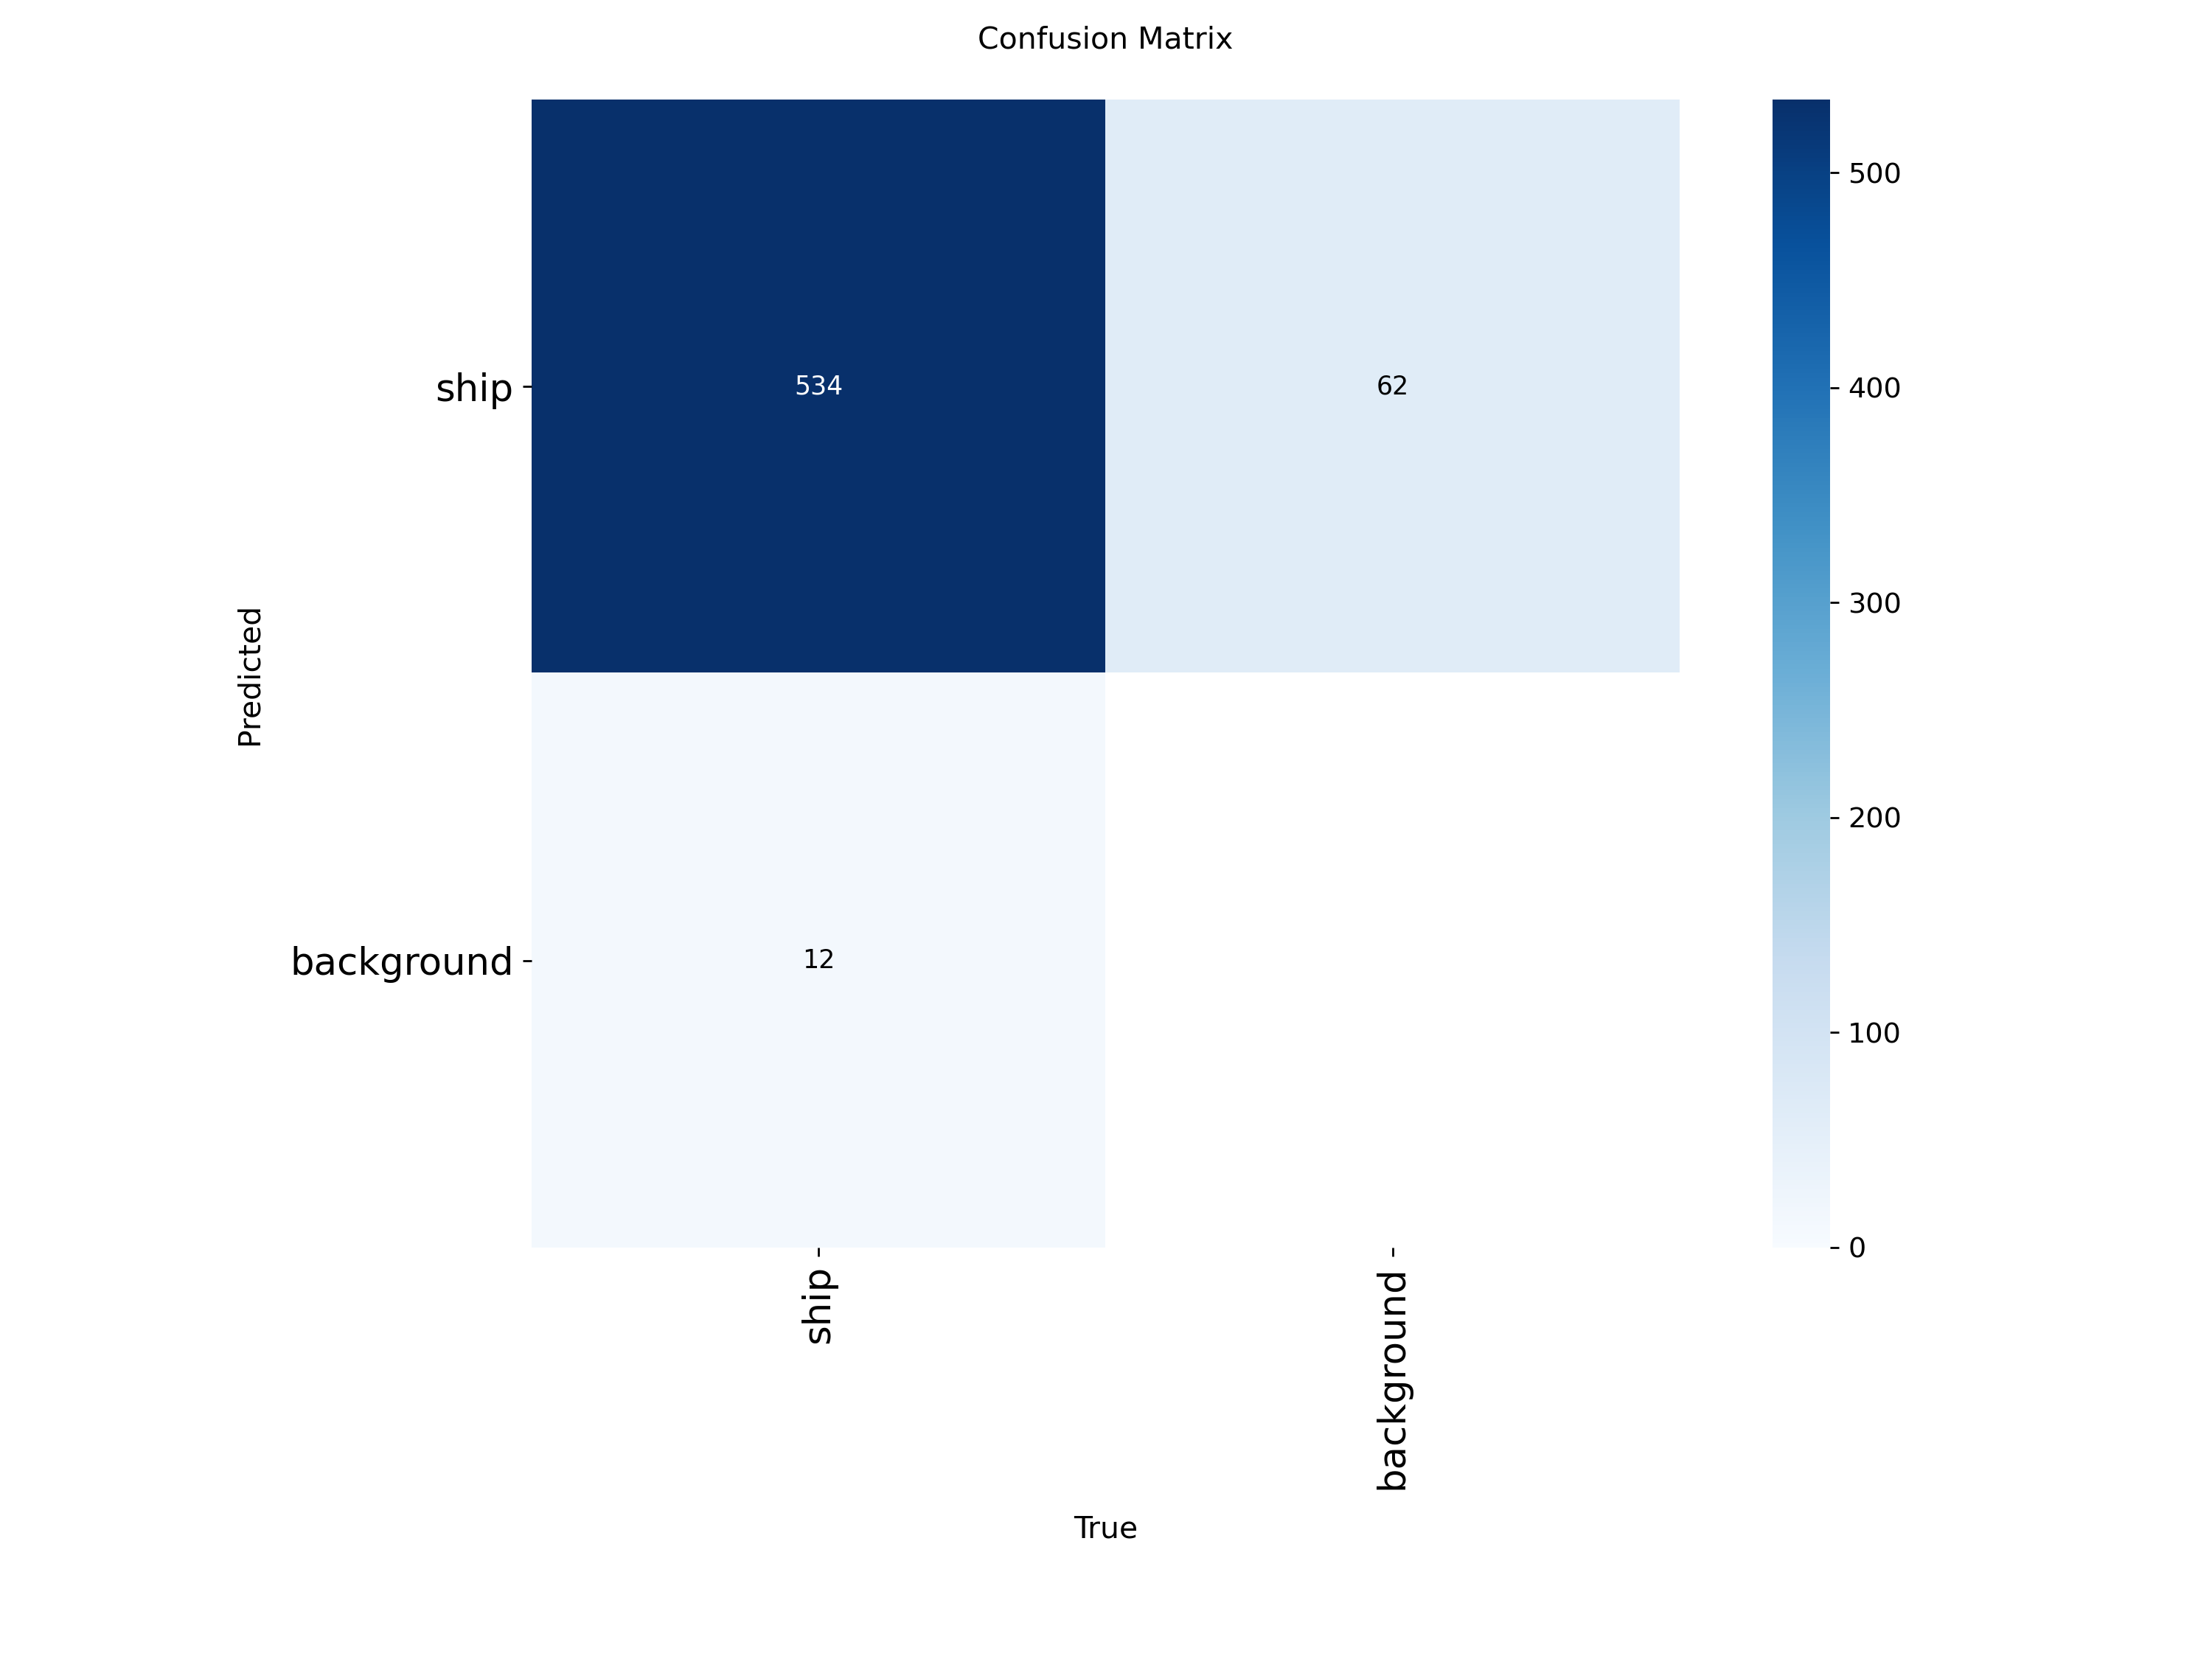

In [9]:
from IPython.display import display, Image

# Displaying Confusion Matrix
display(Image(filename="/kaggle/working/ship_detection/test_evaluation/confusion_matrix.png",
    width=700))